# 🕳️ Null Heatmap

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-quality-governance/null-heatmap/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-quality-governance/null-heatmap/demo.ipynb)

**`df.isna().sum()` answers the wrong question.**

It gives you a per-column count and hides the only thing that matters: whether the nulls are
**independent** or **correlated**.

- 8% missing spread evenly across rows → a nuisance. Impute it.
- 8% missing that always lands on the *same* rows → a broken join or a late-arriving source.
  And `dropna()` will silently delete that entire population.

That second case is how a customer cohort disappears from a model's training data without anyone
noticing. This notebook builds the report that catches it.

### What this notebook covers
1. Three mechanisms hiding behind similar null rates
2. Why Jaccard and not correlation
3. The co-missingness matrix - which columns fail together
4. Row signatures - systematic shape vs random noise
5. **The `dropna()` bias check** - 27.5% of rows, but 87.5% of one channel
6. Two independent axes: column lockstep vs segment skew
7. Chart: null map, co-missingness, and who survives
8. Try your own DataFrame

## Step 1 - Build a frame where the same null rate means three different things

The sample is a customer table with three deliberately different mechanisms:

| Columns | Mechanism | Null rate | What it really is |
|---|---|---|---|
| `age` | scattered | ~6% | a genuinely optional field |
| `card_last4`, `card_expiry` | structural | ~9% | one failed payment-service join |
| `last_login`, `sessions` | structural **and** segment-skewed | ~15% | an activity source that barely covers the `partner` channel |

A per-column count renders all three as "a few percent missing."

In [1]:
from __future__ import annotations

from typing import Dict, Optional

import numpy as np
import pandas as pd

RANDOM_SEED = 42
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 30)


def sample_frame(n: int = 800) -> pd.DataFrame:
    rng = np.random.default_rng(RANDOM_SEED)
    channel = rng.choice(["web", "mobile", "partner"], size=n, p=[0.5, 0.35, 0.15])
    df = pd.DataFrame({
        "customer_id": np.arange(1, n + 1),
        "channel": channel,
        "age": rng.integers(18, 78, n).astype(float),
        "country": rng.choice(["SG", "MY", "ID", "TH"], n),
        "card_last4": [f"{x:04d}" for x in rng.integers(0, 9999, n)],
        "card_expiry": [f"{m:02d}/2{rng.integers(7, 9)}" for m in rng.integers(1, 13, n)],
        "last_login": pd.date_range("2026-07-01", periods=n, freq="1h").astype(str),
        "sessions": rng.integers(1, 60, n).astype(float),
        "lifetime_value": rng.gamma(2.0, 120.0, n).round(2),
    })
    # 1 - scattered: random 6% lose `age`
    df.loc[rng.choice(n, size=int(0.06 * n), replace=False), "age"] = np.nan
    # 2 - structural: the payment join failed, so BOTH card columns die on the same rows
    df.loc[rng.choice(n, size=int(0.09 * n), replace=False),
           ["card_last4", "card_expiry"]] = np.nan
    # 3 - structural AND segment-skewed: activity source barely covers `partner`
    p_fail = np.where(channel == "partner", 0.80, 0.04)
    df.loc[rng.random(n) < p_fail, ["last_login", "sessions"]] = np.nan
    return df


df = sample_frame()
print("what df.isna().sum() tells you:\n")
print(df.isna().sum()[lambda s: s > 0].to_string())
print("\n...three numbers between 48 and 122. Nothing about which rows, or whose.")

what df.isna().sum() tells you:

age             48
card_last4      72
card_expiry     72
last_login     122
sessions       122

...three numbers between 48 and 122. Nothing about which rows, or whose.


## Step 2 - Jaccard, not correlation

The obvious move is to correlate the null indicator columns. For *perfect* lockstep that works
fine - phi hits 1.0. The problem shows up in the middle, so it's worth measuring rather than
asserting.

In [2]:
n = 1000


def compare(rate: float, overlap_frac: float, label: str) -> None:
    """Two columns with the same null rate and a controlled share of shared nulls."""
    k = int(n * rate)
    ov = int(k * overlap_frac)
    a = np.zeros(n, dtype=bool)
    a[:k] = True
    b = np.zeros(n, dtype=bool)
    b[k - ov: k - ov + k] = True
    phi = np.corrcoef(a.astype(float), b.astype(float))[0, 1]
    union = (a | b).sum()
    jac_v = (a & b).sum() / union if union else 0.0
    print(f"{label:<24} phi={phi:+.3f}   jaccard={jac_v:.3f}")


compare(0.02, 1.0, "identical, 2% null")
compare(0.02, 0.5, "half-overlap, 2% null")
compare(0.30, 0.5, "half-overlap, 30% null")
compare(0.02, 0.0, "disjoint, 2% null")

identical, 2% null       phi=+1.000   jaccard=1.000
half-overlap, 2% null    phi=+0.490   jaccard=0.333
half-overlap, 30% null   phi=+0.286   jaccard=0.333
disjoint, 2% null        phi=-0.020   jaccard=0.000


Look at the two middle rows. **The same amount of overlap** - half of each column's nulls shared
with the other - reads as `phi=0.490` when the columns are 2% null and `phi=0.286` when they are
30% null. Phi is base-rate dependent, so its values are not comparable between a column pair that
is barely null and a pair that is mostly null. In a real table every pair has a different base
rate, which is exactly when you need to compare them.

Jaccard returns **0.333** for both, because it asks only the question that matters: *of the rows
missing in either column, what share are missing in both?* Same overlap, same number.

In [3]:
def co_missing_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """Jaccard overlap of null positions between every pair of columns."""
    miss = df.isna()
    cols = list(df.columns)
    m = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)
    for i, ca in enumerate(cols):
        for cb in cols[i:]:
            union = int((miss[ca] | miss[cb]).sum())
            inter = int((miss[ca] & miss[cb]).sum())
            # 0/0 is 0, not 1: two fully-complete columns have nothing to overlap,
            # and calling that a perfect match would flag every clean pair as structural.
            val = round(inter / union, 4) if union else 0.0
            m.loc[ca, cb] = m.loc[cb, ca] = val
    return m


nulled = [c for c in df.columns if df[c].isna().any()]
jac = co_missing_matrix(df)
print(jac.loc[nulled, nulled].to_string())

                age  card_last4  card_expiry  last_login  sessions
age          1.0000      0.0435       0.0435      0.0625    0.0625
card_last4   0.0435      1.0000       1.0000      0.0486    0.0486
card_expiry  0.0435      1.0000       1.0000      0.0486    0.0486
last_login   0.0625      0.0486       0.0486      1.0000    1.0000
sessions     0.0625      0.0486       0.0486      1.0000    1.0000


Two pairs sit at **1.00** - `card_last4`/`card_expiry` and `last_login`/`sessions`. Each pair is
one root cause, not two. Everything else is near zero.

That is already more actionable than four separate null counts: there are **three** problems here,
not five.

## Step 3 - Row signatures

The other view a per-column count can't give: do the nulls form a handful of repeated shapes, or
thousands of unique ones?

In [4]:
def row_patterns(df: pd.DataFrame, top: int = 8) -> pd.DataFrame:
    miss = df.isna()
    sig = miss.apply(lambda r: ", ".join(c for c in df.columns if r[c]) or "(complete)", axis=1)
    counts = sig.value_counts().head(top)
    return pd.DataFrame({
        "missing_columns": counts.index,
        "rows": counts.to_numpy(),
        "share": (counts / len(df)).round(4).to_numpy(),
        "n_cols": [0 if s == "(complete)" else len(s.split(", ")) for s in counts.index],
    })


print(row_patterns(df).to_string(index=False))
print(f"\ndistinct signatures: {df.isna().apply(tuple, axis=1).nunique()} "
      f"out of {len(df)} rows")

                                   missing_columns  rows  share  n_cols
                                        (complete)   580 0.7250       0
                              last_login, sessions   105 0.1312       2
                           card_last4, card_expiry    60 0.0750       2
                                               age    35 0.0438       1
                         age, last_login, sessions     8 0.0100       3
     card_last4, card_expiry, last_login, sessions     7 0.0088       4
                      age, card_last4, card_expiry     3 0.0038       3
age, card_last4, card_expiry, last_login, sessions     2 0.0025       5

distinct signatures: 8 out of 800 rows


Eight signatures cover the whole table, and the top three are exactly the three mechanisms. A
random-noise table would show hundreds of one-off signatures instead.

## Step 4 - The `dropna()` bias check

This is the part that matters for governance. The headline number - how many rows you lose - is
the easy half. The question nobody asks is **who** you lose.

In [5]:
def dropna_cost(df: pd.DataFrame, segment: Optional[str] = None) -> Dict[str, object]:
    complete = df.dropna()
    total, kept = len(df), len(complete)
    out = {"rows_total": total, "rows_kept": kept, "rows_dropped": total - kept,
           "share_dropped": round((total - kept) / total, 4) if total else 0.0}
    if segment and segment in df.columns:
        before = df[segment].value_counts(normalize=True)
        after = complete[segment].value_counts(normalize=True)
        rows = []
        for value in before.index:
            nb = int((df[segment] == value).sum())
            na = int((complete[segment] == value).sum())
            rows.append({"segment": value, "rows_before": nb, "rows_after": na,
                         "retained": round(na / nb, 4) if nb else 0.0,
                         "share_before": round(float(before.get(value, 0)), 4),
                         "share_after": round(float(after.get(value, 0)), 4),
                         "share_shift_pp": round((float(after.get(value, 0))
                                                  - float(before.get(value, 0))) * 100, 2)})
        seg = pd.DataFrame(rows).sort_values("retained")
        out["segment_impact"] = seg
        worst, best = seg.iloc[0], seg.iloc[-1]
        out["bias_warning"] = (
            f"'{worst['segment']}' keeps {worst['retained']:.0%} of its rows while "
            f"'{best['segment']}' keeps {best['retained']:.0%} - dropna() does not drop "
            f"rows, it drops a population."
        ) if worst["retained"] < best["retained"] - 0.15 else None
    return out


d = dropna_cost(df, "channel")
print(f"dropna() deletes {d['rows_dropped']} of {d['rows_total']} rows "
      f"({d['share_dropped']:.1%})\n")
print(d["segment_impact"].to_string(index=False))
print(f"\n{d['bias_warning']}")

dropna() deletes 220 of 800 rows (27.5%)

segment  rows_before  rows_after  retained  share_before  share_after  share_shift_pp
partner          112          14    0.1250        0.1400       0.0241          -11.59
    web          405         331    0.8173        0.5062       0.5707            6.44
 mobile          283         235    0.8304        0.3538       0.4052            5.14

'partner' keeps 12% of its rows while 'mobile' keeps 83% - dropna() does not drop rows, it drops a population.


**27.5% of rows - but 87.5% of the `partner` channel.**

`partner` goes from 14.0% of the population to 2.4%, an 11.6 percentage-point collapse. Train
anything on `df.dropna()` and it has essentially never seen a partner customer. The row count in
the log would read "dropped 220 rows," which sounds like housekeeping.

## Step 5 - Two axes, not one

Both column pairs score Jaccard **1.00**. They are not the same kind of problem, and the
difference only shows up on a second axis - completeness spread across a segment.

In [6]:
SEGMENT_SKEW_THRESHOLD = 0.30


def segment_spread(df: pd.DataFrame, segment: str) -> pd.Series:
    """Completeness gap across segment values, per column."""
    mask = df.isna().copy()
    mask.insert(0, "__seg__", df[segment].to_numpy())
    comp = 1 - mask.groupby("__seg__", observed=True).mean()
    return (comp.max() - comp.min()).drop(labels=[segment], errors="ignore")


spread = segment_spread(df, "channel")
summary_tbl = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "completeness": (1 - df.isna().mean()).round(4),
    "best_partner_jaccard": [
        max([jac.loc[c, o] for o in nulled if o != c], default=0.0) for c in df.columns
    ],
    "segment_spread": spread.reindex(df.columns).fillna(0.0).round(3),
})
summary_tbl = summary_tbl[summary_tbl["n_missing"] > 0]
summary_tbl["verdict"] = np.where(
    summary_tbl["segment_spread"] >= SEGMENT_SKEW_THRESHOLD,
    "governance problem - removes a population",
    np.where(summary_tbl["best_partner_jaccard"] >= 0.9,
             "engineering bug - one join, hit everyone equally",
             "imputable - independent nulls"),
)
print(summary_tbl.to_string())

             n_missing  completeness  best_partner_jaccard  segment_spread                                           verdict
age                 48        0.9400                0.0625           0.018                     imputable - independent nulls
card_last4          72        0.9100                1.0000           0.021  engineering bug - one join, hit everyone equally
card_expiry         72        0.9100                1.0000           0.021  engineering bug - one join, hit everyone equally
last_login         122        0.8475                1.0000           0.823         governance problem - removes a population
sessions           122        0.8475                1.0000           0.823         governance problem - removes a population


Same Jaccard, opposite conclusions:

- `card_last4` / `card_expiry` — lockstep **1.00**, segment spread **0.02**. A failed join that
  hit every channel equally. Fix the pipeline; dropping these rows costs you no population.
- `last_login` / `sessions` — lockstep **1.00**, segment spread **0.82**. `partner` is 14%
  complete against 97% everywhere else. Fixing the pipeline is not enough; anything already
  trained on the complete-rows-only view is biased.

Column lockstep tells you **how many root causes** there are. Segment spread tells you **who
pays**. Reporting only the first is how the second one ships.

## Step 6 - The picture

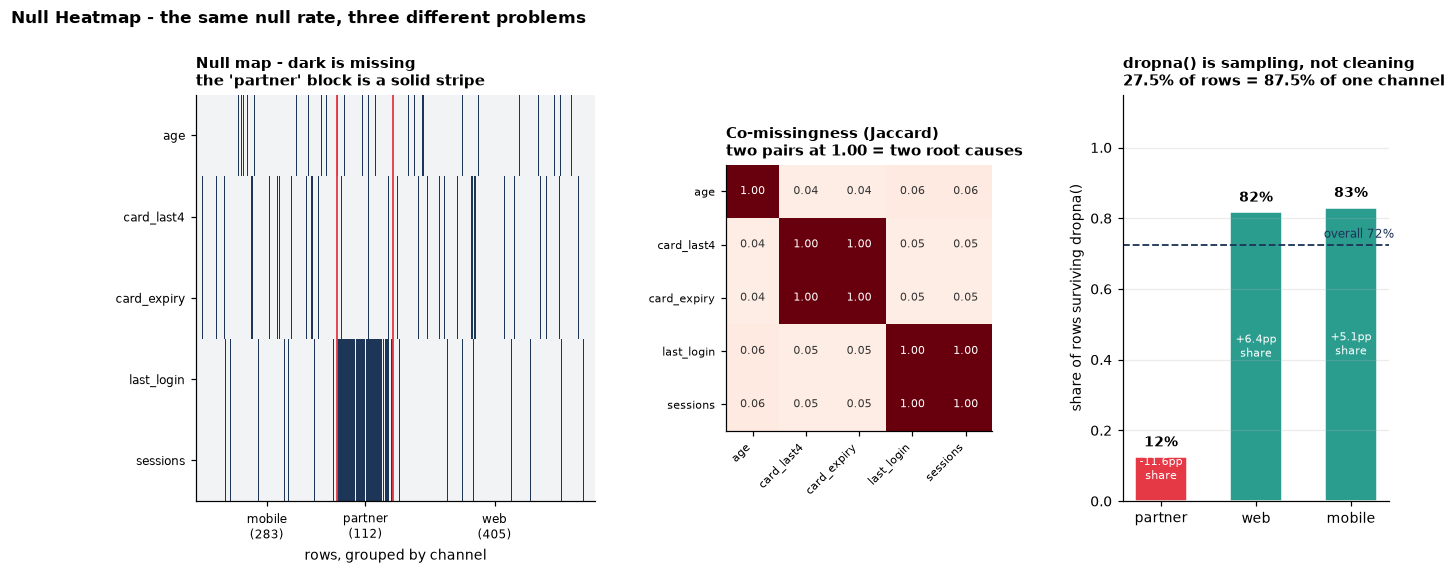

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": False,
                     "axes.spines.top": False, "axes.spines.right": False})

fig = plt.figure(figsize=(14, 4.8))
gs = fig.add_gridspec(1, 3, width_ratios=[1.5, 1.0, 1.0], wspace=0.42)

# --- 1: the null map, rows sorted by channel so the stripe is visible
ax1 = fig.add_subplot(gs[0, 0])
order = df.sort_values("channel").index
mask = df.loc[order, nulled].isna().to_numpy().T
ax1.imshow(mask, aspect="auto", cmap=ListedColormap(["#f1f3f5", "#1d3557"]),
           interpolation="nearest")
ax1.set_yticks(range(len(nulled)))
ax1.set_yticklabels(nulled, fontsize=8)
bounds, pos = [], 0
for ch in df.loc[order, "channel"].unique():
    cnt = int((df["channel"] == ch).sum())
    bounds.append((pos + cnt / 2, f"{ch}\n({cnt})"))
    pos += cnt
    if pos < len(df):
        ax1.axvline(pos, color="#e63946", lw=1.2)
ax1.set_xticks([c for c, _ in bounds])
ax1.set_xticklabels([lbl for _, lbl in bounds], fontsize=8)
ax1.set_xlabel("rows, grouped by channel")
ax1.set_title("Null map - dark is missing\nthe 'partner' block is a solid stripe",
              loc="left", fontweight="bold", fontsize=9.5)

# --- 2: co-missingness
ax2 = fig.add_subplot(gs[0, 1])
sub = jac.loc[nulled, nulled]
im = ax2.imshow(sub.to_numpy(), cmap="Reds", vmin=0, vmax=1)
ax2.set_xticks(range(len(nulled)))
ax2.set_xticklabels(nulled, rotation=45, ha="right", fontsize=7.5)
ax2.set_yticks(range(len(nulled)))
ax2.set_yticklabels(nulled, fontsize=7.5)
for i in range(len(nulled)):
    for j in range(len(nulled)):
        v = sub.iloc[i, j]
        ax2.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                 color="white" if v > 0.55 else "#333")
ax2.set_title("Co-missingness (Jaccard)\ntwo pairs at 1.00 = two root causes",
              loc="left", fontweight="bold", fontsize=9.5)

# --- 3: who survives dropna()
ax3 = fig.add_subplot(gs[0, 2])
ax3.grid(axis="y", alpha=0.25)
si = d["segment_impact"]
colors = ["#e63946" if r < 0.5 else "#2a9d8f" for r in si["retained"]]
bars = ax3.bar(si["segment"], si["retained"], color=colors, edgecolor="white", width=0.55)
for b, r, shift in zip(bars, si["retained"], si["share_shift_pp"]):
    ax3.text(b.get_x() + b.get_width() / 2, r + 0.03, f"{r:.0%}", ha="center",
             fontsize=9, fontweight="bold")
    ax3.text(b.get_x() + b.get_width() / 2, r / 2, f"{shift:+.1f}pp\nshare",
             ha="center", fontsize=7.5, color="white")
ax3.axhline(1 - d["share_dropped"], ls="--", lw=1.2, color="#1d3557")
ax3.text(2.45, 1 - d["share_dropped"] + 0.02, f"overall {1 - d['share_dropped']:.0%}",
         ha="right", fontsize=8, color="#1d3557")
ax3.set_ylim(0, 1.15)
ax3.set_ylabel("share of rows surviving dropna()")
ax3.set_title("dropna() is sampling, not cleaning\n27.5% of rows = 87.5% of one channel",
              loc="left", fontweight="bold", fontsize=9.5)

fig.suptitle("Null Heatmap - the same null rate, three different problems",
             fontsize=11, fontweight="bold", x=0.005, ha="left", y=1.04)
fig.savefig("null_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Columns | Null rate | Jaccard | Segment spread | Verdict |
|---|---|---|---|---|
| `age` | 6% | 0.06 | 0.02 | imputable - independent nulls |
| `card_last4` + `card_expiry` | 9% | **1.00** | 0.02 | engineering bug - one join, hit everyone equally |
| `last_login` + `sessions` | 15% | **1.00** | **0.82** | governance problem - removes a population |

`dropna()`: **220 of 800 rows (27.5%)** - but **87.5% of the `partner` channel**, whose share of
the population falls from 14.0% to 2.4%.

**The takeaway:** a per-column null count cannot distinguish any of these three rows from each
other. Report the co-missingness matrix to find out *how many* problems you have, and the segment
spread to find out *who pays for them*. Then never call `dropna()` without printing the second
table first.

## Try your own DataFrame

In [8]:
# --- point this at your own data ----------------------------------------
# mine = pd.read_csv("my_data.csv")
# nulled_mine = [c for c in mine.columns if mine[c].isna().any()]
# print(co_missing_matrix(mine).loc[nulled_mine, nulled_mine].to_string())
# print(row_patterns(mine).to_string(index=False))
# d_mine = dropna_cost(mine, segment="your_segment_column")
# print(d_mine["segment_impact"].to_string(index=False), d_mine["bias_warning"], sep="\n")

# Demo: what a genuinely random-missing frame looks like, for contrast.
rng2 = np.random.default_rng(7)
clean = pd.DataFrame(rng2.normal(size=(500, 5)), columns=list("abcde"))
clean = clean.mask(rng2.random(clean.shape) < 0.06)
cj = co_missing_matrix(clean)
off_diag = [cj.loc[a, b] for i, a in enumerate(clean.columns) for b in clean.columns[i + 1:]]
print(f"MCAR frame: max pairwise jaccard {max(off_diag):.3f} "
      f"(vs 1.000 in the sample), "
      f"{clean.isna().apply(tuple, axis=1).nunique()} distinct signatures in 500 rows")
print(f"dropna() would delete {dropna_cost(clean)['share_dropped']:.1%} of rows - "
      "evenly, from nobody in particular.")

MCAR frame: max pairwise jaccard 0.117 (vs 1.000 in the sample), 15 distinct signatures in 500 rows
dropna() would delete 24.6% of rows - evenly, from nobody in particular.


---

**Day 129** of the daily FDE build - **Data Quality & Governance** line.

Companions: **Day 91** [`anomaly-detector`](../anomaly-detector),
**Day 92** [`dq-rules-engine`](../dq-rules-engine) (turn these findings into enforced rules),
**Day 28** [`data-quality-scorecard`](../../analytics-accelerator/data-quality-scorecard).

```bash
pip install -r requirements.txt
streamlit run app.py       # 5 tabs, upload your own CSV
python missingness.py      # CLI report
```

← [Back to the portfolio](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-quality-governance/null-heatmap)